In [5]:
import numpy as np
import torch
import math

# If you have SNR_dB_array and Psi_all defined in a config module, import them:
# from lib.config import SNR_dB_array, Psi_all

def compute_psi_for_snr(snr_db, SNR_dB_array, Psi_all):
    """
    Return Psi corresponding to the given SNR (snr_db).
    SNR_dB_array : 1D numpy array of SNR dB values used when building Psi_all
    Psi_all       : numpy array with shape (num_SNRs, N, N) (complex) or torch tensor
    """
    # Use numpy search (works if SNR_dB_array is numpy)
    idx = int(np.argmin(np.abs(np.asarray(SNR_dB_array) - snr_db)))
    psi = Psi_all[idx]
    # ensure torch tensor of complex dtype
    if not torch.is_tensor(psi):
        psi = torch.tensor(psi, dtype=torch.complex64)
    return psi


def steering_vector_torch(theta_deg, N, device=None, dtype=torch.complex64, degrees=True):
    """
    Steering vector for a ULA with half-wavelength spacing.
    theta_deg : scalar or 1D array/tensor of angles in degrees (default)
    Returns:
       a : tensor shape (N, T) where T = number of angles
           dtype is complex (default torch.complex64)
    """
    if not torch.is_tensor(theta_deg):
        theta = torch.tensor(theta_deg, dtype=torch.float32)
    else:
        theta = theta_deg.to(torch.float32)

    device = device or (theta.device if torch.is_tensor(theta_deg) else torch.device('cpu'))
    theta = theta.to(device)

    if degrees:
        theta_rad = theta * (math.pi / 180.0)
    else:
        theta_rad = theta

    # ensure theta is 1D
    if theta_rad.ndim == 0:
        theta_rad = theta_rad.view(1)
    T = theta_rad.numel()

    n = torch.arange(0, N, dtype=torch.float32, device=device).view(N, 1)          # (N,1)
    sin_t = torch.sin(theta_rad).view(1, T)                                       # (1,T)

    # cast to complex for multiplication
    n_c = n.to(torch.complex64)
    sin_t_c = sin_t.to(torch.complex64)

    a = torch.exp(1j * math.pi * (n_c @ sin_t_c)) / torch.sqrt(torch.tensor(float(N), device=device))
    # a shape: (N, T), complex
    return a


def benchmark_beampattern_torch(Psi, theta_grid_deg, N, device=None, normalize=True):
    """
    Compute beampattern B(θ) = a^H(θ) Psi a(θ) for Psi (N,N) or batch (B,N,N).
    Args:
      Psi           : torch tensor complex64 with shape (N,N) or (B,N,N) OR numpy array
      theta_grid_deg: 1D tensor/array of angles in degrees (len T)
      N             : number of antennas
      device        : torch device (optional)
      normalize     : if True, normalize each batch row by its max -> values in [0,1]
    Returns:
      B : torch.real tensor of shape (T,) for single Psi or (B, T) for batched Psi
    """
    # convert theta grid to torch
    if not torch.is_tensor(theta_grid_deg):
        theta_grid = torch.tensor(theta_grid_deg, dtype=torch.float32)
    else:
        theta_grid = theta_grid_deg.to(torch.float32)

    # convert Psi to tensor
    if not torch.is_tensor(Psi):
        Psi_t = torch.tensor(Psi, dtype=torch.complex64)
    else:
        Psi_t = Psi.to(torch.complex64)

    device = device or Psi_t.device
    Psi_t = Psi_t.to(device)
    theta_grid = theta_grid.to(device)

    T = theta_grid.numel()

    # create steering matrix (N, T)
    a = steering_vector_torch(theta_grid, N, device=device)  # (N, T), complex

    # If Psi_t is single (N,N), create a batch
    if Psi_t.ndim == 2:
        Psi_batch = Psi_t.unsqueeze(0)            # (1, N, N)
    elif Psi_t.ndim == 3:
        Psi_batch = Psi_t                         # (B, N, N)
    else:
        raise ValueError("Psi must have shape (N,N) or (B,N,N)")

    B = Psi_batch.shape[0]   # batch size

    # Expand a to (B, N, T)
    a_batch = a.unsqueeze(0).repeat(B, 1, 1)   # (B, N, T)

    # Compute a^H Psi a for each batch and theta:
    # result shape (B, T)
    # einsum notation: conj(a) * (Psi @ a) summing over N
    Psi_a = torch.einsum("bnm,bmt->bnt", Psi_batch, a_batch)           # (B, N, T)
    B_theta = torch.einsum("btn,bnt->bt", a_batch.conj().transpose(1,2), Psi_a)  # (B, T)  (note: aH * Psi_a)
    B_theta = B_theta.real

    if normalize:
        max_vals = B_theta.amax(dim=1, keepdim=True) + 1e-12
        B_theta = B_theta / max_vals

    # squeeze if single
    if Psi_t.ndim == 2:
        return B_theta.squeeze(0)   # (T,)
    return B_theta                # (B, T)


def desired_beampattern_torch(theta_grid_deg, theta_targets_deg, width_deg=5.0, device=None):
    """
    Desired beampattern: ones inside width_deg of each target, zero elsewhere.
    Inputs in degrees.
    Outputs a torch float tensor shape (T,)
    """
    if not torch.is_tensor(theta_grid_deg):
        theta_grid = torch.tensor(theta_grid_deg, dtype=torch.float32)
    else:
        theta_grid = theta_grid_deg.to(torch.float32)
    device = device or theta_grid.device
    theta_grid = theta_grid.to(device)

    targets = torch.tensor(theta_targets_deg, dtype=torch.float32, device=device).view(-1, 1)  # (P,1)
    grid = theta_grid.view(1, -1)   # (1, T)
    mask = torch.any(torch.abs(grid - targets) <= width_deg, dim=0)
    return mask.float()   # (T,)


def sensing_beampattern_torch(A, D, theta_grid_deg, device=None, normalize=True):
    """
    Compute sensing beampattern from hybrid precoders A and D:
      B(θ) = a^H(θ) * (A D D^H A^H) * a(θ)
    Accepts:
      A : (N,M) or (B,N,M) torch tensor (complex)
      D : (M,K) or (B,M,K) torch tensor (complex)
    Returns:
      B : (T,) if single-sample or (B,T) if batched
    """
    # convert theta grid
    if not torch.is_tensor(theta_grid_deg):
        theta_grid = torch.tensor(theta_grid_deg, dtype=torch.float32)
    else:
        theta_grid = theta_grid_deg.to(torch.float32)

    device = device or (A.device if torch.is_tensor(A) else torch.device('cpu'))
    theta_grid = theta_grid.to(device)

    # ensure tensors and dtypes
    if not torch.is_tensor(A):
        A = torch.tensor(A, dtype=torch.complex64, device=device)
    else:
        A = A.to(device).to(torch.complex64)
    if not torch.is_tensor(D):
        D = torch.tensor(D, dtype=torch.complex64, device=device)
    else:
        D = D.to(device).to(torch.complex64)

    single = False
    if A.ndim == 2:
        single = True
        A = A.unsqueeze(0)   # (1,N,M)
        D = D.unsqueeze(0)   # (1,M,K)

    B_batch, N, M_ = A.shape
    T = theta_grid.numel()

    # Sensing covariance: S = A D D^H A^H  -> (B,N,N)
    DDH = torch.bmm(D, D.conj().transpose(1, 2))            # (B,M,M)
    S_cov = torch.bmm(torch.bmm(A, DDH), A.conj().transpose(1, 2))  # (B,N,N)

    # steering matrix (N,T)
    a = steering_vector_torch(theta_grid, N, device=device)   # (N,T)
    a_batch = a.unsqueeze(0).repeat(B_batch, 1, 1)            # (B,N,T)

    # compute B(θ) = a^H S_cov a  -> (B,T)
    S_a = torch.einsum("bnm,bmt->bnt", S_cov, a_batch)         # (B,N,T)
    B_theta = torch.einsum("bnt,bnt->bt", a_batch.conj().transpose(1,2), S_a).real  # (B,T)

    if normalize:
        B_theta = B_theta / (B_theta.amax(dim=1, keepdim=True) + 1e-12)

    return B_theta.squeeze(0) if single else B_theta


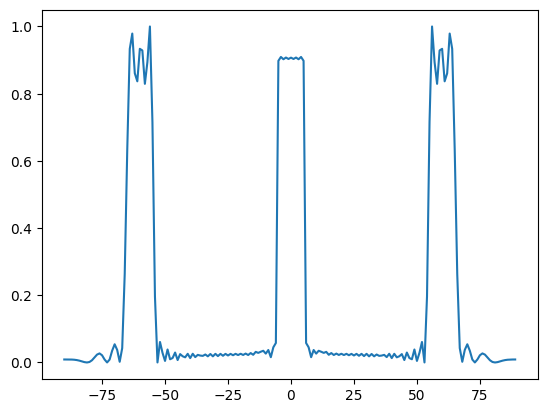

In [9]:

Psi = compute_psi(SNR_dB_array[-1])  # Example usage
B_bench = benchmark_beampattern_torch(Psi, theta_grid_deg, N=64, device=device)
plt.plot(theta_grid_deg, B_bench)

In [ ]:
# === Setup ===
from lib.config import *
from lib.support_functions_torch import compute_psi, generate_channel_torch_batch, proposed_initialization_torch_batch, run_pga_torch_batch


num_realizations = 10
snr_db = 12

P_BS = sigma_n2 * 10 ** (snr_db / 10)
P_BS_t = torch.full((num_realizations,), P_BS, dtype=torch.float32, device=device)

# convert PSI to torch
Psi_np = compute_psi(snr_db)
Psi_t = torch.tensor(Psi_np, dtype=torch.complex64, device=device)

theta_grid_t = torch.linspace(-90, 90, 181, device=device)
Psi_batch = torch.stack([Psi_t for _ in range(num_realizations)], dim=0).to(device)

# === Channel generation ===
H_batch = generate_channel_torch_batch(N, M, L=L, batch_size=num_realizations, device=device)

# === Initialization ===
A0_batch, D0_batch = proposed_initialization_torch_batch(H_batch, theta_d, N, M, K, P_BS_t, device=device)

# === Run PGA ===
with torch.no_grad():
    _, _, _, A_batch, D_batch= run_pga_torch_batch(
        H=H_batch,
        A0=A0_batch,
        D0=D0_batch,
        J=1,
        I_max=I_max,
        mu=-0.01,
        lambda_=0.01,
        omega=omega,
        sigma_n2=sigma_n2,
        Psi=Psi_batch,
        P_BS=P_BS_t,
        device=device
    )
# === Compute beampatterns ===
B_bench = benchmark_beampattern_torch(Psi_batch, theta_grid_t, N, device=device)
B_sense = sensing_beampattern_torch(A_batch, D_batch, theta_grid_t, device=device)

# === Average across realizations ===
B_bench_avg = B_bench.mean(dim=0)
B_sense_avg = B_sense.mean(dim=0)

# === Plot ===
plt.figure(figsize=(8,5))
plt.plot(theta_grid_t.cpu(), B_bench_avg.cpu(), 'r-', linewidth=2, label='Benchmark')
plt.plot(theta_grid_t.cpu(), B_sense_avg.cpu(), 'b--', linewidth=2, label='Sensing (PGA)')
plt.xlabel("Angle (°)")
plt.ylabel("Normalized Power")
plt.title("Benchmark vs PGA Sensing Beampattern (Averaged)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


grad_tau_D range: 1.115419626235962 183.22039794921875
Shape of A_batch: torch.Size([10, 64, 4]), D_batch: torch.Size([10, 4, 4])


RuntimeError: einsum(): subscript n has size 64 for operand 1 which does not broadcast with previously seen size 181